Deep Learning is a subset of ML which uses neural networks it is inspired from the stucture and functions of the neural network of the human brain.It is able to work on huge amount of data it can solve complex problems and can autimatically extract the feature and patterns from the data.
In ML training training is fast and testing is compatively slow where as in deep learning training is very slow and testing is fast.

w1,w2,w3....wn represents the weights which shows the strength of a particular node 
b represents the bias value it allows us to move or to shift the activation function up or down,then the products are summed then fed to the activation function to generate a result and this result is same as output.

Activation function it decides whether a neuron is activated or not my calculationg the weighted sum and further add the bias to it. 
Linear-for continous data            fn range
Sigmoid-for catogorical
TanH(Hyperbolic tangent)-for catogorical
ReLU(Rectified Linear unit)-for catogorical and continous it converts all the neg number into zero and keep all the positive number as it is 


Loss Function:-
1)regeression:-
  1)mean squared error
  2)mean absolute error
2)classification
  1)binary crossentropy 
  2)catogorical crossentropy 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
ad=pd.read_csv(r"C:\Users\mishr\OneDrive\Desktop\advertising.csv")
ad

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [3]:
ip=ad.drop('Sales',axis=1)
ip

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [4]:
op=ad.Sales
op

0      22.1
1      10.4
2      12.0
3      16.5
4      17.9
       ... 
195     7.6
196    14.0
197    14.8
198    25.5
199    18.4
Name: Sales, Length: 200, dtype: float64

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    ip,
    op,
    train_size=0.8,
    random_state=3000
)

In [6]:

from sklearn.preprocessing import StandardScaler

sc = StandardScaler() 
x_train = sc.fit_transform(x_train) 

x_test = sc.transform(x_test) 

In [ ]:
import tensorflow as tf

# Import Keras, TensorFlow's high-level API for building and training neural networks
from tensorflow import keras
# Import the Sequential model for creating layer-by-layer neural networks
from tensorflow.keras.models import Sequential
# Import Dense layer (fully connected neural network layer)
from keras.layers import Dense
# Import Adam optimizer for updating model weights during training
from keras.optimizers import Adam

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [ ]:
# Model training 

# Create a Sequential Neural Network model
model = Sequential()

# Input layer & first hidden layer
model.add(Dense(30,input_dim=3,activation="linear"))   # first 30 hidden layers, dimension 3 , then input layer
# first hidden layer
# Linear activation passes values directly to the next layer
model.add(Dense(25, activation="linear"))              # 25 neurons
model.add(Dense(10, activation="linear"))              # 20 neurons
model.add(Dense(1, activation="linear"))               # 1 neuron # Output layer
# Adam = Adaptive Moment Estimation optimizer
# It automatically adjusts the learning rate during training
# learning_rate=0.01 controls how much weights are updated each step
model.compile(Adam(learning_rate=0.01),loss="mse")

C:\Users\mishr\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()
# Display the model architecture, output shapes, and total trainable parameters

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │           775 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,166 (4.55 KB)

 Trainable params: 1,166 (4.55 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=20)# epochs = 20
# The entire training dataset is passed through the network 20 times

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 241.7595 - val_loss: 208.2049
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 171.4311 - val_loss: 136.7057
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 92.9050 - val_loss: 48.9138
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 22.0981 - val_loss: 4.7896
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 16.4720 - val_loss: 16.2254
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 13.9406 - val_loss: 6.1056
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 4.4907 - val_loss: 2.8435
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 5.4342 - val_loss: 4.6162
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 5.0793 - val_loss: 4.5585
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 3.7500 - val_loss: 2.3182
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 2.8872 - val_loss: 2.1154
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 3.4647 - val_

In [11]:
y_pred = model.predict(x_test)
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Mean Squared Error: 2.05
R-squared: 0.92


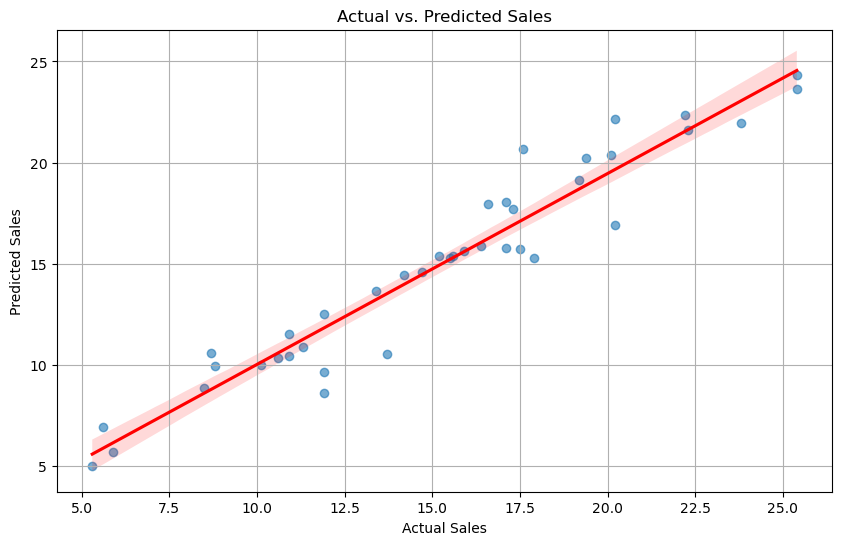

In [12]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred.flatten(), scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs. Predicted Sales")
plt.grid(True)
plt.show()